<a href="https://colab.research.google.com/github/maoyuqing50-code/tryaimama/blob/main/wikipedia_analysis_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wikipedia EN — Linguistic Analysis (v5)
### IS-618

**What this notebook does:**
1. Loads pre-matched contested/stable article pairs from `final_pairs_en_strict.json`
2. Extracts **7 linguistic features** across Category 1 (F1–F2), Category 2 (F3–F5), Category 3 (F6–F7)
3. Runs **Wilcoxon signed-rank tests** on matched pairs with Holm correction (with r_rb effect size)
4. Runs **logistic regression** with topic controls
5. Produces **Bootstrap 95% CI**, VIF check, coefficient plot, Spearman correlation heatmap


**Feature map:**
| ID  | Feature                        | Category | Direction |
|-----|----------------------------------|-------|-----------|
| F1  | Epistemic hedge density          | C1    | C > S     |
| F2  | Affective stance marker density  | C1    | C > S     |
| F3  | Verification-evading expression density              | C2    | C > S     |
| F4  | Attribution verb bias ratio      | C2    | C > S     |
| F5  | Lexical presupposition density (LLM)   | C2    | C > S     |
| F6  | Contrastive transition density   | C3    | S > C     |
| F7  | Lexical diversity (MTLD)         | C3    | C > S     |





## 0. Install Dependencies

In [1]:

!pip install -q lexicalrichness statsmodels transformers torch spacy seaborn requests
!python -m spacy download en_core_web_sm -q
print('Done')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 102.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Done


## 0b. Mount Google Drive & Set Checkpoint Paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
CHECKPOINT_DIR = '/content/drive/MyDrive/wiki_project/checkpoints/'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

F5_CHECKPOINT = CHECKPOINT_DIR + 'f5_entailment_scores.csv'
print(f'Checkpoint dir: {CHECKPOINT_DIR}')


Mounted at /content/drive
Checkpoint dir: /content/drive/MyDrive/wiki_project/checkpoints/


## 1. Imports

In [3]:
import requests
import json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy.stats as stats
warnings.filterwarnings('ignore')

from collections import Counter
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.utils import resample
from lexicalrichness import LexicalRichness

import spacy
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])
nlp.add_pipe('sentencizer')
print('Imports OK | spaCy loaded')


Imports OK | spaCy loaded


## Before running

```python
from google.colab import files
files.upload()
```


## 1b. Load Pre-Matched Pairs

In [4]:
with open('final_pairs_en_strict.json', encoding='utf-8') as f:
    pairs = json.load(f)

records = []
for p in pairs:
    for role, art in [('contested', p['contested']), ('stable', p['stable'])]:
        records.append({
            'title'     : art['title'],
            'label'     : art['label'],        # 0=contested, 1=stable
            'text'      : art['clean_text'],
            'topic'     : art['topic'],
            'word_count': art['word_count'],
            'age_days'  : art['age_days'],
            'pair_id'   : p['contested']['title'],
        })
df = pd.DataFrame(records)
print(f'Total articles : {len(df)}')
print(f'Labels         : {df.label.value_counts().to_dict()}')
print(f'Topics         : {df.topic.value_counts().to_dict()}')


Total articles : 286
Labels         : {0: 143, 1: 143}
Topics         : {'geography': 76, 'science': 76, 'culture': 74, 'politics_history': 60}


## 2. Word Lists & Feature Functions

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# WORD LISTS
# ══════════════════════════════════════════════════════════════════════════════

# ── F1: Epistemic Hedge Density ────────────────────────────────────────────────
# Hyland (2018, pp. 271–272) Appendix
# claim/claimed/claims and argue/argued/argues removed to avoid double-counting with F4 BIASED_REPORT and NEUTRAL_REPORT
HEDGES = [
    # ── Modal auxiliaries — epistemic possibility/necessity ──────────────────
    'could', "couldn't", 'may', 'might', 'ought', 'should', 'would',

    # ── Epistemic verbs — express writer's uncertain judgment ────────────────
    'appear', 'appeared', 'appears',
    'assume', 'assumed',
    'doubt',
    'estimate', 'estimated',
    'feel', 'feels', 'felt',
    'guess',
    'indicate', 'indicated', 'indicates',
    'postulate', 'postulated', 'postulates',
    'seem', 'seems',
    'suggest', 'suggested', 'suggests',
    'suppose', 'supposed', 'supposes',
    'suspect', 'suspects',
    'tend to', 'tended to', 'tends to',

    # ── Probability adverbs/adjectives — signal degree of certainty ──────────
    'apparently',
    'doubtful',
    'likely',
    'maybe',
    'perhaps',
    'plausible', 'plausibly',
    'possible', 'possibly',
    'presumable', 'presumably',
    'probable', 'probably',
    'uncertain', 'uncertainly',
    'unclear', 'unclearly',
    'unlikely',

    # ── Perspective markers — attribute proposition to writer's view ─────────
    'from my perspective', 'from our perspective', 'from this perspective',
    'in my opinion', 'in my view', 'in this view',
    'in our opinion', 'in our view',
    'to my knowledge',
]

# ── F2: Affective Stance Marker Density ───────────────────────────────────────
# Hyland (2018, pp. 268–269) attitude markers UNION MPQA strong subjectives (negative-polarity strongsubj entries
HYLAND_ATTITUDE = [
    'admittedly',
    'agree', 'agreed', 'agrees',
    'amazed', 'amazing', 'amazingly',
    'appropriate', 'appropriately',
    'astonished', 'astonishing', 'astonishingly',
    'correctly',
    'curious', 'curiously',
    'desirable', 'desirably',
    'disappointed', 'disappointing', 'disappointingly',
    'disagree', 'disagreed', 'disagrees',
    'dramatic', 'dramatically',
    'essential',
    'expected', 'expectedly',
    'fortunate', 'fortunately',
    'hopeful', 'hopefully',
    'important', 'importantly',
    'inappropriate', 'inappropriately',
    'interesting', 'interestingly',
    'prefer', 'preferable', 'preferably', 'preferred',
    'remarkable', 'remarkably',
    'shocked', 'shocking', 'shockingly',
    'striking', 'strikingly',
    'surprised', 'surprising', 'surprisingly',
    'unbelievable', 'unbelievably',
    'understandable', 'understandably',
    'unexpected', 'unexpectedly',
    'unfortunate', 'unfortunately',
    'unusual', 'unusually',
]

# ── MPQA strong subjectives, negative polarity ────────────────────────────────
# Mirror used because mpqa.cs.pitt.edu requires a request form for direct download.
MPQA_URL = 'https://raw.githubusercontent.com/cltl/VUA_pylib/master/lexicon/data/subjclueslen1-HLTEMNLP05.tff'


def load_mpqa_negative_strongsubj(url=MPQA_URL):
    resp = requests.get(url)
    resp.raise_for_status()
    words = set()
    for line in resp.text.splitlines():
        line = line.strip()
        if not line:
            continue
        fields = dict(kv.split('=', 1) for kv in line.split() if '=' in kv)
        if fields.get('type') == 'strongsubj' and fields.get('priorpolarity') == 'negative':
            words.add(fields.get('word1', ''))
    return words

# Words already covered by F1, F3, F4; removed here to avoid double-counting across features.
F2_OVERLAP_WITH_OTHER_FEATURES = {
    'doubt', 'doubtful',       # already in F1 HEDGES
    'so-called', 'obviously',  # already in F3 VERIFICATION_EVADING_EXPRESSIONS
    'contend', 'accuse',       # already in F4 BIASED_REPORT
}

mpqa_negative_strongsubj = load_mpqa_negative_strongsubj() - F2_OVERLAP_WITH_OTHER_FEATURES
print(f'MPQA negative strong-subjective words loaded: {len(mpqa_negative_strongsubj)}')

AFFECTIVE_MARKERS = list(dict.fromkeys(HYLAND_ATTITUDE + sorted(mpqa_negative_strongsubj)))
print(f'Total F2 word list size: {len(AFFECTIVE_MARKERS)}')

# ── F3: Verification-Evading Expression Density ─────────────────────────────────────────────
# Wikipedia "Words to Watch" (en.wikipedia.org/wiki/Wikipedia:Manual_of_Style/Words_to_watch)
#two categories: vague attribution; self-certifying evaluatives (includes a small set of promotional terms that the source page discusses separately as "peacock terms")
VERIFICATION_EVADING_EXPRESSIONS = [
    # Category 1: Vague attribution phrases
    'some people', 'many people', 'most people',
    'experts say', 'experts claim',
    'it is said', 'it is believed', 'it has been suggested', 'it is often said',
    'it is claimed', 'it is argued', 'it is thought',
    'researchers say', 'scientists say', 'historians say', 'critics say',
    'studies show', 'research shows',
    'according to some', 'some argue', 'some believe',
    'supposed', 'alleged', 'purported', 'so-called',
    # Category 2: Self-certifying evaluatives
    'of course', 'naturally', 'obviously', 'clearly', 'undoubtedly',
    'it goes without saying', 'needless to say',
    'it is important to note', 'it is worth noting', 'it should be noted',
    'importantly', 'interestingly', 'notably', 'significantly',
    'seemingly', 'supposedly', 'purportedly', 'arguably',
    'legendary', 'groundbreaking', 'revolutionary', 'world-class',
    'cutting-edge', 'state-of-the-art', 'unique'
]

# ── F4: Attribution Verb Bias Ratio ───────────────────────────────────────────
# Neutral/biased report verb distinction follows the assertive predicate
# classification in Hooper (1975), described in similar terms by Recasens et al. (2013).
# Both word lists below are manually curated subsets of the 'report_verbs' set in the NELAFeatures toolkit (Horne, Nørregaard & Adali, 2019; itself built on Recasens et al. 2013), which does not distinguish
# neutral from biased verbs internally, the neutral/biased split and the ratio itself are our own construction.
NEUTRAL_REPORT = {
    'say', 'state', 'report', 'describe', 'explain',
    'note', 'indicate', 'write', 'mention', 'observe',
    'add', 'comment', 'declare', 'inform', 'tell',
    'express', 'reply', 'respond', 'answer',
}
BIASED_REPORT = {
    'claim', 'allege', 'insist', 'contend', 'assert',
    'charge', 'accuse', 'argue', 'maintain', 'suggest', 'imply',
}

# ── F6: Contrastive Transition Density ────────────────────────────────────────
# Hyland (2018, pp. 267–268) Appendix Transition Markers, restricted to adversative/concessive subset
CONTRASTIVE_TRANSITIONS = [
    'although', 'but', 'by contrast', 'conversely', 'even though',
    'however', 'nevertheless', 'nonetheless', 'on the contrary',
    'on the other hand', 'rather', 'still', 'though', 'whereas',
    'while', 'yet',
]

print('Word lists ready')
print(f'  F1 hedges          : {len(HEDGES)} terms')
print(f'  F2 affective markers    : {len(AFFECTIVE_MARKERS)} terms')
print(f'  F3 verification-evading   : {len(VERIFICATION_EVADING_EXPRESSIONS)} terms')
print(f'  F4 biased/neutral report  : {len(BIASED_REPORT)} / {len(NEUTRAL_REPORT)}')
print(f'  F6 contrastive trans    : {len(CONTRASTIVE_TRANSITIONS)} terms')


MPQA negative strong-subjective words loaded: 3073
Total F2 word list size: 3121
Word lists ready
  F1 hedges          : 65 terms
  F2 affective markers    : 3121 terms
  F3 verification-evading   : 50 terms
  F4 biased/neutral report  : 11 / 19
  F6 contrastive trans    : 16 terms


## 2b. Feature Extraction Functions (F1–F7)

In [6]:

# ══════════════════════════════════════════════════════════════════════════════
# FEATURE FUNCTIONS (F1–F7 lexical/statistical; F5 uses NLI — loaded in §3b)
# ══════════════════════════════════════════════════════════════════════════════

def _density(text, wordlist):
    """
    Count wordlist matches per 1,000 tokens.
    Multi-word phrases matched by substring; single words protected by
    regex word boundaries to prevent sub-string false positives
    (e.g. 'but' inside 'button', 'many' inside 'Germany').
    """
    if not text or not text.strip():
        return 0.0
    t = text.lower()
    n = max(len(t.split()), 1)
    count = 0
    for w in wordlist:
        if ' ' in w:
            # Multi-word phrase: plain substring match is sufficient
            count += t.count(w)
        else:
            # Single word: enforce word boundaries
            count += len(re.findall(r'\b' + re.escape(w) + r'\b', t))
    return round(count / n * 1000, 4)

# F1 — Epistemic hedge density (word list: see HEDGES above)
def f1_hedge_density(text):
    return _density(text, HEDGES)

# F2 — Affective stance marker density (word list: see AFFECTIVE_MARKERS above)
def f2_affective_density(text):
    return _density(text, AFFECTIVE_MARKERS)

# F3 — Verification-evading expression density (word list: see VERIFICATION_EVADING_EXPRESSIONS above)
def f3_verification_evading_density(text):
    return _density(text, VERIFICATION_EVADING_EXPRESSIONS)

# F4 — Attribution verb bias ratio (word lists: see BIASED_REPORT/NEUTRAL_REPORT above)
# spaCy lemmatisation applied to original-case text; lemmas lowercased
# before matching to avoid case-sensitivity issues while preserving
# lemmatisation accuracy.
def f4_attribution_bias(text):
    """
    Ratio of biased to total report verbs via spaCy lemmatisation.
    Returns NaN if total report verb count < 3 (insufficient evidence).
    """
    if not text or not text.strip():
        return np.nan
    doc = nlp(text)  # original case preserved for accurate lemmatisation
    lemmas = [token.lemma_.lower() for token in doc if token.pos_ == 'VERB']
    biased  = sum(1 for l in lemmas if l in BIASED_REPORT)
    neutral = sum(1 for l in lemmas if l in NEUTRAL_REPORT)
    total   = biased + neutral
    if total < 3:
        return np.nan
    return round(biased / total, 4)

# F6 — Contrastive transition density (word list: see CONTRASTIVE_TRANSITIONS above)
def f6_contrastive_density(text):
    return _density(text, CONTRASTIVE_TRANSITIONS)

# F7 — Lexical diversity (MTLD)
# threshold=0.72 (standard); minimum 50 tokens required for stable estimate;
# algorithm is language-agnostic
def f7_mtld(text):
    if not text or len(text.split()) < 50:
        return np.nan
    try:
        return round(LexicalRichness(text).mtld(threshold=0.72), 4)
    except:
        return np.nan

# _is_classifiable filter — used by F5
def _is_classifiable(sent_text):
    """
    Filter out sentences that cannot carry epistemological bias.
    Requires minimum 6 tokens and at least one finite verb.
    """
    tokens = sent_text.strip().split()
    if len(tokens) < 6:
        return False
    doc = nlp(sent_text)
    if not any(t.pos_ == 'VERB' for t in doc):
        return False
    return True

print('Feature functions F1–F4, F6, F7 ready')

Feature functions F1–F4, F6, F7 ready


## 3. Apply Lexical Features (F1–F4, F6, F7)

In [7]:
print('Computing F1–F4, F6, F7 (lexical)...')
df['f1_hedge']                = df['text'].apply(f1_hedge_density)
df['f2_affective']            = df['text'].apply(f2_affective_density)
df['f3_verification_evading'] = df['text'].apply(f3_verification_evading_density)
df['f4_attrib_bias']          = df['text'].apply(f4_attribution_bias)
df['f6_contrastive']          = df['text'].apply(f6_contrastive_density)
df['f7_mtld']                 = df['text'].apply(f7_mtld)
print('Done — F1, F2, F3, F4, F6, F7 computed')
print(df[['f1_hedge','f2_affective','f3_verification_evading','f4_attrib_bias','f6_contrastive','f7_mtld']].describe().round(4))


Computing F1–F4, F6, F7 (lexical)...
Done — F1, F2, F3, F4, F6, F7 computed
       f1_hedge  f2_affective  f3_verification_evading  f4_attrib_bias  \
count  286.0000      286.0000                 286.0000        233.0000   
mean     4.8745       10.8140                   0.6190          0.2510   
std      4.3117        8.7297                   0.9458          0.2294   
min      0.0000        0.0000                   0.0000          0.0000   
25%      2.1708        5.4756                   0.0000          0.0000   
50%      3.9892        8.8799                   0.2690          0.2000   
75%      6.6649       13.5700                   0.9279          0.4000   
max     45.4545       57.3711                   9.2166          1.0000   

       f6_contrastive   f7_mtld  
count        286.0000  286.0000  
mean           4.5540   71.0577  
std            3.1211   18.0467  
min            0.0000   15.2746  
25%            2.3180   57.7134  
50%            4.2565   70.8153  
75%            6.21

## 3b. LLM Features (F5)



In [8]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
print(f'Device: {"GPU" if device == 0 else "CPU"}')


print('Loading NLI model (mDeBERTa-v3-base-xnli-multilingual-nli-2mil7)...')
nli_pipe = pipeline(
    'zero-shot-classification',
    model='MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7',
    device=device,
)
print('NLI model loaded')


Device: GPU
Loading NLI model (mDeBERTa-v3-base-xnli-multilingual-nli-2mil7)...


config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

NLI model loaded


In [9]:
# ── F5: Lexical presupposition density (LLM) ──────────────────────────────────
# mDeBERTa-v3-base-xnli-multilingual-nli-2mil7 (Laurer et al. 2022)
# hypothesis_template: {} filled by candidate_labels=['biased', 'neutral']

ENTAIL_HYPOTHESIS = (
    "This sentence contains a word or phrase whose meaning "
    "presupposes or entails a one-sided stance towards a "
    "contested event, person, or claim. The sentence is {}."
)

def _nli_density(text, hypothesis):
    """
    Proportion of classifiable sentences per article where NLI model
    assigns entailment score > 0.5 to the given hypothesis.
    Denominator is total classifiable sentences (not all sentences).
    Returns NaN for empty or fully unclassifiable texts.
    """
    if not text or not text.strip():
        return np.nan
    doc   = nlp(text)
    sents = [s.text.strip() for s in doc.sents if _is_classifiable(s.text)]
    if not sents:
        return np.nan
    sents_trunc = [s[:512] for s in sents]
    results = nli_pipe(
        sents_trunc,
        candidate_labels=['biased', 'neutral'],
        hypothesis_template=hypothesis,
        multi_label=False,
    )
    entail_count = sum(
        1 for r in results
        if r['labels'][0] == 'biased' and r['scores'][0] > 0.5
    )
    return round(entail_count / len(sents), 4)

def f5_presupposition_density(text):
    """
    F5: Lexical presupposition density.
    Proportion of classifiable sentences where a word or phrase
    presupposes or entails a one-sided stance towards a contested
    event, person, or claim, via zero-shot NLI.
    Source: Laurer et al. (2022).
    """
    return _nli_density(text, ENTAIL_HYPOTHESIS)

print('F5 function ready (uses nli_pipe loaded in §3b)')

F5 function ready (uses nli_pipe loaded in §3b)


In [10]:
import os

# ── Compute F5 with checkpointing ─────────────────────────────────────────────

if os.path.exists(F5_CHECKPOINT):
    print(f'Loading F5 from checkpoint: {F5_CHECKPOINT}')
    f5_ckpt = pd.read_csv(F5_CHECKPOINT, index_col=0)
    # Backward-compat: older checkpoints were saved under the column name
    # 'f5_entailment' before the feature was renamed to 'f5_presupposition'.
    if 'f5_presupposition' not in f5_ckpt.columns and 'f5_entailment' in f5_ckpt.columns:
        f5_ckpt = f5_ckpt.rename(columns={'f5_entailment': 'f5_presupposition'})
        f5_ckpt.to_csv(F5_CHECKPOINT)
        print('  Checkpoint column renamed f5_entailment → f5_presupposition (file updated in place)')
    df['f5_presupposition'] = df['title'].map(f5_ckpt['f5_presupposition'])
else:
    print(f'Computing F5 (presupposition density, NLI) — {len(df)} articles...')
    f5_scores = {}
    for count, (i, row) in enumerate(df.iterrows(), start=1):
        f5_scores[row['title']] = f5_presupposition_density(row['text'])
        if count % 50 == 0:
            ckpt = pd.DataFrame.from_dict(
                f5_scores, orient='index', columns=['f5_presupposition']
            )
            ckpt.to_csv(F5_CHECKPOINT)
            print(f'  [{count}/{len(df)}] F5 checkpoint saved')
    df['f5_presupposition'] = df['title'].map(f5_scores)
    ckpt = pd.DataFrame.from_dict(
        f5_scores, orient='index', columns=['f5_presupposition']
    )
    ckpt.to_csv(F5_CHECKPOINT)
    print(f'F5 done — {len(f5_scores)} articles processed. Checkpoint: {F5_CHECKPOINT}')

Loading F5 from checkpoint: /content/drive/MyDrive/wiki_project/checkpoints/f5_entailment_scores.csv


## 4. Feature Maps & Descriptive Stats

In [11]:
# ── Feature maps (F1–F7) ─────
LING_FEATURES = ['f1_hedge', 'f2_affective', 'f3_verification_evading', 'f4_attrib_bias',
                 'f5_presupposition', 'f6_contrastive', 'f7_mtld']

LABELS = {
    'f1_hedge'               : 'F1 Epistemic hedges',
    'f2_affective'         : 'F2 Affective stance markers',
    'f3_verification_evading'  : 'F3 Verification-evading expression density',
    'f4_attrib_bias'      : 'F4 Attribution bias ratio',
    'f5_presupposition'           : 'F5 Lexical Presupposition Density',
    'f6_contrastive'         : 'F6 Contrastive transitions',
    'f7_mtld'                : 'F7 Lexical diversity (MTLD)',
}

CATEGORY_MAP = {
    'f1_hedge'             : 'C1',
    'f2_affective'           : 'C1',
    'f3_verification_evading'     : 'C2',
    'f4_attrib_bias'          : 'C2',
    'f5_presupposition'        : 'C2',
    'f6_contrastive'          : 'C3',
    'f7_mtld'              : 'C3',
}

PREDICTED = {
    'f1_hedge'               : +1,   # C > S
    'f2_affective'          : +1,   # C > S
    'f3_verification_evading': +1,  # C > S
    'f4_attrib_bias'         : +1,   # C > S
    'f5_presupposition'      : +1,   # C > S
    'f6_contrastive'   : -1,   # S > C
    'f7_mtld'                : +1,   # C > S
}

c_df = df[df.label == 0]
s_df = df[df.label == 1]

print(f'{"Feature":<30} {"Contested":>10} {"Stable":>10} {"Diff%":>8}  {"Dir":>5}  Category')
print('-' * 75)
n_correct = 0
for f in LING_FEATURES:
    cm   = c_df[f].mean()
    sm   = s_df[f].mean()
    diff = (cm - sm) / (abs(sm) + 1e-9) * 100
    ok   = '✓' if ((cm > sm) == (PREDICTED[f] == 1)) else '✗'
    if ok == '✓': n_correct += 1
    print(f'{LABELS[f]:<30} {cm:>10.4f} {sm:>10.4f} {diff:>+8.1f}%  {ok:>5}   {CATEGORY_MAP[f]}')

print(f'\nDirection correct: {n_correct}/{len(LING_FEATURES)}')


Feature                         Contested     Stable    Diff%    Dir  Category
---------------------------------------------------------------------------
F1 Epistemic hedges                4.5109     5.2381    -13.9%      ✗   C1
F2 Affective stance markers       12.8191     8.8088    +45.5%      ✓   C1
F3 Verification-evading expression density     0.8262     0.4118   +100.6%      ✓   C2
F4 Attribution bias ratio          0.3352     0.1585   +111.6%      ✓   C2
F5 Lexical Presupposition Density     0.4791     0.4390     +9.1%      ✓   C2
F6 Contrastive transitions         4.1040     5.0040    -18.0%      ✓   C3
F7 Lexical diversity (MTLD)       74.9075    67.2079    +11.5%      ✓   C3

Direction correct: 6/7


## 5. NaN Report

In [12]:
nan_counts = df[LING_FEATURES].isna().sum()
print('NaN counts per feature:')
for f in LING_FEATURES:
    pct  = nan_counts[f] / len(df) * 100
    flag = '  ⚠ >10%' if pct > 10 else ''
    print(f'  {LABELS[f]:<30} {nan_counts[f]:>5} ({pct:.1f}%){flag}')

NaN counts per feature:
  F1 Epistemic hedges                0 (0.0%)
  F2 Affective stance markers        0 (0.0%)
  F3 Verification-evading expression density     0 (0.0%)
  F4 Attribution bias ratio         53 (18.5%)  ⚠ >10%
  F5 Lexical Presupposition Density     0 (0.0%)
  F6 Contrastive transitions         0 (0.0%)
  F7 Lexical diversity (MTLD)        0 (0.0%)


## 6. VIF Check

In [13]:
df_vif = df[LING_FEATURES].dropna()
X_vif  = StandardScaler().fit_transform(df_vif.values)

vif_vals = [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]

print(f'{"Feature":<30} {"VIF":>8}  Status')
print('-' * 55)
for f, v in zip(LING_FEATURES, vif_vals):
    status = 'OK' if v < 5 else ('WARN (consider merge)' if v < 10 else 'HIGH — must merge')
    print(f'{LABELS[f]:<30} {v:>8.2f}  {status}')

print('\nRule: VIF < 5 keep | 5–10 consider merging | >10 must merge')


Feature                             VIF  Status
-------------------------------------------------------
F1 Epistemic hedges                1.22  OK
F2 Affective stance markers        1.26  OK
F3 Verification-evading expression density     1.08  OK
F4 Attribution bias ratio          1.12  OK
F5 Lexical Presupposition Density     1.34  OK
F6 Contrastive transitions         1.35  OK
F7 Lexical diversity (MTLD)        1.25  OK

Rule: VIF < 5 keep | 5–10 consider merging | >10 must merge


## 7. Wilcoxon Signed-Rank Tests on Matched Pairs

In [14]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import numpy as np

diff_records = []
for p in pairs:
    c_title = p['contested']['title']
    s_title = p['stable']['title']
    c_row   = df[df.title == c_title]
    s_row   = df[df.title == s_title]
    if c_row.empty or s_row.empty: continue
    c_row, s_row = c_row.iloc[0], s_row.iloc[0]
    rec = {f: c_row[f] - s_row[f] for f in LING_FEATURES}
    rec['pair_id'] = c_title
    diff_records.append(rec)

diff_df = pd.DataFrame(diff_records)
print(f'Valid pairs for Wilcoxon: {len(diff_df)}\n')

raw_results = []
for f in LING_FEATURES:
    vals = diff_df[f].dropna()
    if len(vals) < 5: continue
    stat, p_val = wilcoxon(vals)
    n = len(vals)
    # Convert W statistic to z-score, then to rank-biserial correlation r_rb
    # Formula: z = (W - E[W]) / SD[W]; r_rb = |z| / sqrt(n)
    mean_w = n * (n + 1) / 4
    std_w  = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)
    z      = (stat - mean_w) / std_w
    r_rb   = round(abs(z) / np.sqrt(n), 3)
    raw_results.append({
        'feature'   : f,
        'mean_diff' : vals.mean(),
        'pct_c_hi'  : (vals > 0).mean() * 100,
        'p_raw'     : p_val,
        'r_rb'      : r_rb,
        'n'         : n,
    })

# Holm correction across all features
p_vals        = [r['p_raw'] for r in raw_results]
_, p_holm, _, _ = multipletests(p_vals, method='holm')
for r, p_h in zip(raw_results, p_holm):
    r['p_holm'] = p_h
    r['sig']    = ('***' if p_h < 0.001 else
                   '**'  if p_h < 0.01  else
                   '*'   if p_h < 0.05  else
                   '~'   if p_h < 0.10  else 'ns')
    r['effect'] = ('large'  if r['r_rb'] >= 0.5 else
                   'medium' if r['r_rb'] >= 0.3 else
                   'small'  if r['r_rb'] >= 0.1 else 'negligible')

print(f'{"Feature":<30} {"Mean Δ":>9} {"C>S%":>7} {"p (Holm)":>10} {"r_rb":>6} {"Effect":<10}  Sig   Category')
print('-' * 90)
for r in raw_results:
    f = r['feature']
    print(f'{LABELS[f]:<30} {r["mean_diff"]:>+9.4f} {r["pct_c_hi"]:>6.1f}% '
          f'{r["p_holm"]:>10.4f} {r["r_rb"]:>6.3f} {r["effect"]:<10}  {r["sig"]:<5} {CATEGORY_MAP[f]}')

n_sig = sum(1 for r in raw_results if r['p_holm'] < 0.05)
print(f'\n* p<.05  ** p<.01  *** p<.001  ~ p<.10  ns = not significant (Holm-corrected)')
print(f'Significant features (p<.05): {n_sig}/{len(LING_FEATURES)}')
print(f'Effect size: small r>=.1  medium r>=.3  large r>=.5 (rank-biserial)')

Valid pairs for Wilcoxon: 143

Feature                           Mean Δ    C>S%   p (Holm)   r_rb Effect      Sig   Category
------------------------------------------------------------------------------------------
F1 Epistemic hedges              -0.7273   44.8%     0.2086  0.105 small       ns    C1
F2 Affective stance markers      +4.0103   61.5%     0.0005  0.324 medium      ***   C1
F3 Verification-evading expression density   +0.4144   56.6%     0.0000  0.625 large       ***   C2
F4 Attribution bias ratio        +0.1829   72.6%     0.0000  0.550 large       ***   C2
F5 Lexical Presupposition Density   +0.0401   59.4%     0.0721  0.186 small       ~     C2
F6 Contrastive transitions       -0.9000   37.8%     0.0102  0.245 small       *     C3
F7 Lexical diversity (MTLD)      +7.6997   62.9%     0.0018  0.294 small       **    C3

* p<.05  ** p<.01  *** p<.001  ~ p<.10  ns = not significant (Holm-corrected)
Significant features (p<.05): 5/7
Effect size: small r>=.1  medium r>=.3  

## 8. Logistic Regression with Topic Controls

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Baseline computed once on full dataset to ensure consistent comparison
base = max(df['label'].mean(), 1 - df['label'].mean())

feature_sets = {
    'Authorial commitment only' : [f for f in LING_FEATURES if CATEGORY_MAP[f] == 'C1'],
    'Source transparency only'  : [f for f in LING_FEATURES if CATEGORY_MAP[f] == 'C2'],
    'Textual organisation only' : [f for f in LING_FEATURES if CATEGORY_MAP[f] == 'C3'],
    'All 7 linguistic'          : LING_FEATURES,
}

print(f'{"Feature set":<30} {"F1":>8} {"Acc":>8} {"vs baseline":>12}')
print('-' * 62)

results = {}
for name, feats in feature_sets.items():
    avail = [f for f in feats if f in df.columns]
    d     = df[avail + ['label']].dropna()
    if len(d) < 20 or len(avail) < 1: continue
    X    = StandardScaler().fit_transform(d[avail].values)
    y    = d['label'].values
    f1s  = cross_val_score(lr, X, y, cv=cv, scoring='f1_macro')
    accs = cross_val_score(lr, X, y, cv=cv, scoring='accuracy')
    results[name] = {'f1': f1s.mean(), 'acc': accs.mean(), 'f1_std': f1s.std()}
    print(f'{name:<30} {f1s.mean():>8.3f} {accs.mean():>8.3f} {accs.mean()-base:>+12.3f}')

print(f'\nMajority-class baseline: {base:.3f}')

Feature set                          F1      Acc  vs baseline
--------------------------------------------------------------
Authorial commitment only         0.582    0.584       +0.084
Source transparency only          0.694    0.695       +0.195
Textual organisation only         0.625    0.626       +0.126
All 7 linguistic                  0.738    0.738       +0.238

Majority-class baseline: 0.500


## 9. Bootstrap 95% Confidence Intervals

In [16]:
from sklearn.utils import resample

d_full     = df[LING_FEATURES + ['label']].dropna()
X_full     = StandardScaler().fit_transform(d_full[LING_FEATURES].values)
y_full     = d_full['label'].values

# Fit on full data for point estimates; separate instance to avoid
# overwriting the CV model used in the classification section
lr_boot = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_boot.fit(X_full, y_full)

# Bootstrap CI (1000 iterations, fixed seeds for reproducibility)
coef_boot = []
for seed in range(1000):
    X_b, y_b = resample(X_full, y_full, random_state=seed)
    if len(set(y_b)) < 2:
        continue
    m = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    m.fit(X_b, y_b)
    coef_boot.append(m.coef_[0])

coef_arr = np.array(coef_boot)

print(f'Bootstrap iterations completed: {len(coef_boot)}/1000')
print(f'\n{"Feature":<30} {"Coef":>8} {"95% CI":>22} {"Width":>7}  Stable?  Category')
print('-' * 92)

stable_feats, unstable_feats = [], []
ci_widths = {}

for i, f in enumerate(LING_FEATURES):
    lo    = np.percentile(coef_arr[:, i], 2.5)
    hi    = np.percentile(coef_arr[:, i], 97.5)
    c     = lr_boot.coef_[0][i]
    width = round(hi - lo, 3)
    ok    = 'YES' if (lo > 0 or hi < 0) else 'unstable'
    ci_widths[f] = width
    if ok == 'YES':
        stable_feats.append(f)
    else:
        unstable_feats.append(f)
    print(f'{LABELS.get(f, f):<30} {c:>+8.3f} [{lo:>+7.3f}, {hi:>+7.3f}] {width:>7.3f}  {ok:<9} {CATEGORY_MAP.get(f, "")}')

print(f'\nCI width summary (narrower = more precise):')
for f in LING_FEATURES:
    if f in ci_widths:
        print(f'  {LABELS[f]:<30} width={ci_widths[f]:.3f}')

print(f'\nStable features   ({len(stable_feats)}): {[LABELS[f] for f in stable_feats]}')
print(f'Unstable features ({len(unstable_feats)}): {[LABELS[f] for f in unstable_feats]}')


Bootstrap iterations completed: 1000/1000

Feature                            Coef                 95% CI   Width  Stable?  Category
--------------------------------------------------------------------------------------------
F1 Epistemic hedges              +0.444 [ +0.051,  +0.806]   0.755  YES       C1
F2 Affective stance markers      -0.726 [ -1.283,  -0.380]   0.903  YES       C1
F3 Verification-evading expression density   -0.541 [ -1.436,  -0.197]   1.239  YES       C2
F4 Attribution bias ratio        -0.972 [ -1.379,  -0.643]   0.736  YES       C2
F5 Lexical Presupposition Density   -0.428 [ -0.821,  -0.122]   0.699  YES       C2
F6 Contrastive transitions       +0.499 [ +0.157,  +0.938]   0.781  YES       C3
F7 Lexical diversity (MTLD)      -0.451 [ -0.889,  -0.061]   0.828  YES       C3

CI width summary (narrower = more precise):
  F1 Epistemic hedges            width=0.755
  F2 Affective stance markers    width=0.903
  F3 Verification-evading expression density width=1.239


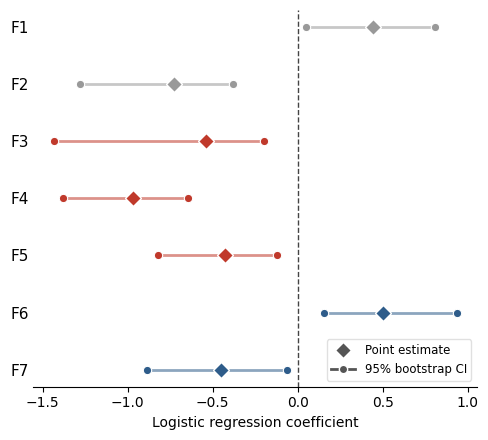

Saved: fig_bootstrap_dumbbell.png


In [17]:
# ── Figure: Bootstrap 95% CI dumbbell plot ───────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

CATEGORY_COLORS = {'C1': '#999999', 'C2': '#C0392B', 'C3': '#2E5C8A'}

order = LING_FEATURES
ys = range(len(order))
short_labels = [LABELS[f].split()[0] for f in order]  # "F1", "F2", ...

fig, ax = plt.subplots(figsize=(5, 4.5))

for i, f in enumerate(order):
    idx   = LING_FEATURES.index(f)
    coef  = lr_boot.coef_[0][idx]
    lo    = np.percentile(coef_arr[:, idx], 2.5)
    hi    = np.percentile(coef_arr[:, idx], 97.5)
    color = CATEGORY_COLORS[CATEGORY_MAP[f]]

    ax.plot([lo, hi], [i, i], color=color, linewidth=2, zorder=2, alpha=0.55)
    ax.plot([lo, hi], [i, i], 'o', color=color, markersize=6, zorder=3,
             markeredgecolor='white', markeredgewidth=0.8)
    ax.plot(coef, i, 'D', color=color, markersize=8, zorder=4,
             markeredgecolor='white', markeredgewidth=1)

ax.axvline(0, color='#444444', linewidth=1, linestyle='--', zorder=1)

ax.set_yticks(list(ys))
ax.set_yticklabels(short_labels, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Logistic regression coefficient', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

# Marker-shape legend: diamond = point estimate, capped line = 95% CI
legend_elems = [
    Line2D([0], [0], marker='D', color='none', markerfacecolor='#555555',
           markeredgecolor='white', markersize=8, label='Point estimate'),
    Line2D([0], [0], marker='o', color='#555555', markerfacecolor='#555555',
           markeredgecolor='white', markersize=6, linewidth=2, label='95% bootstrap CI'),
]
ax.legend(handles=legend_elems, fontsize=8.5, loc='lower right',
          framealpha=0.9, edgecolor='#DDDDDD')

plt.tight_layout()
plt.savefig('fig_bootstrap_dumbbell.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig_bootstrap_dumbbell.png')

## 10. Visualisations

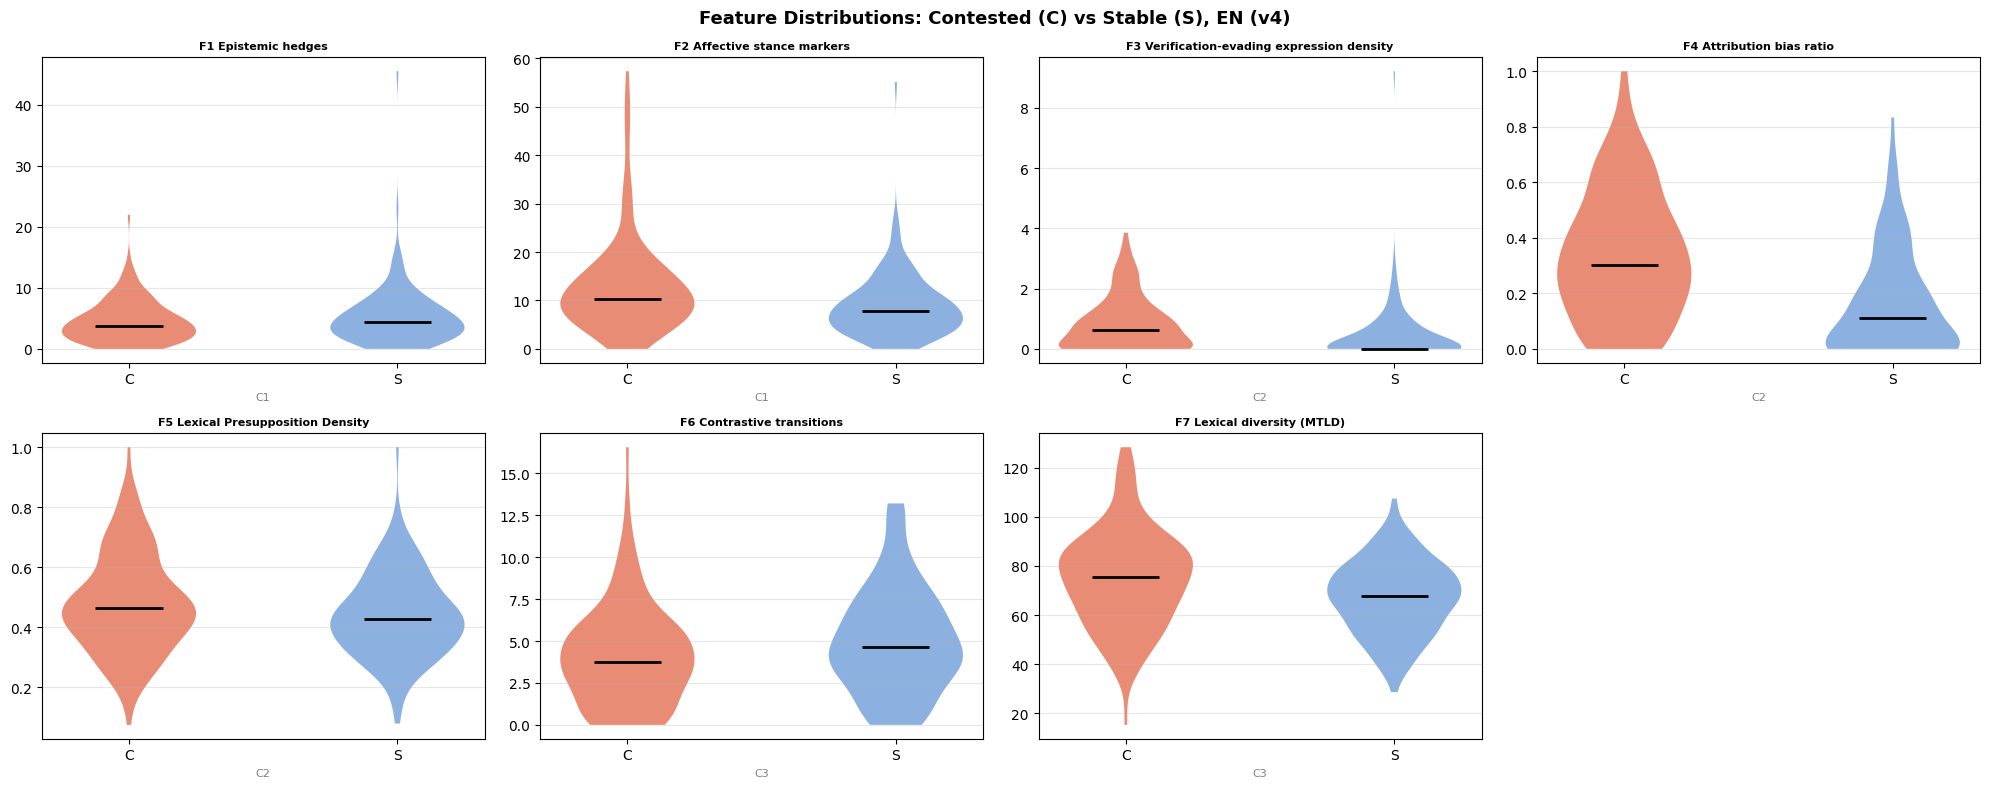

Saved: distributions_v4.png


In [18]:
# ── Violin plots (7 panels) ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes_flat = axes.flatten()

for ax, f in zip(axes_flat, LING_FEATURES):
    c_vals = df[df.label == 0][f].dropna()
    s_vals = df[df.label == 1][f].dropna()
    parts  = ax.violinplot([c_vals.values, s_vals.values],
                            positions=[0, 1], showmedians=True, showextrema=False)
    for body, color in zip(parts['bodies'], ['#E05C3A', '#5B8FD4']):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['C', 'S'], fontsize=10)
    ax.set_title(LABELS[f], fontsize=8, fontweight='bold')
    ax.set_xlabel(CATEGORY_MAP[f], fontsize=8, color='gray')
    ax.grid(axis='y', alpha=0.3)

# Hide unused panel
axes_flat[-1].set_visible(False)

fig.suptitle('Feature Distributions: Contested (C) vs Stable (S), EN (v4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: distributions_v4.png')


## 11. Summary Table

In [19]:

def effect_size_label(r_rb):
    if r_rb >= 0.5:
        return 'large'
    elif r_rb >= 0.3:
        return 'medium'
    elif r_rb >= 0.1:
        return 'small'
    else:
        return 'negligible'

print('=' * 100)
print('RESULTS SUMMARY, EN (v4, 7 features)')
print('=' * 100)
print(f'\nPairs loaded: {len(pairs)}')

print(f'\n{"Feature":<45} {"Dir":>5} {"Wilcoxon":>10} {"r_rb":>6} {"Effect":>10} {"Boot CI":>10}  Category')
print('-' * 100)

for r in raw_results:
    f  = r['feature']
    if f not in LING_FEATURES: continue
    i     = LING_FEATURES.index(f)
    lo    = np.percentile(coef_arr[:, i], 2.5)
    hi    = np.percentile(coef_arr[:, i], 97.5)
    ci_ok = 'stable' if (lo > 0 or hi < 0) else 'unstable'
    cm    = c_df[f].mean()
    sm    = s_df[f].mean()
    dir_ok = '✓' if ((cm > sm) == (PREDICTED[f] == 1)) else '✗'
    eff   = effect_size_label(r['r_rb'])
    print(f'{LABELS[f]:<45} {dir_ok:>5} {r["sig"]:>10} '
          f'{r["r_rb"]:>6.3f} {eff:>10} {ci_ok:>10}  {CATEGORY_MAP[f]}')

RESULTS SUMMARY, EN (v4, 7 features)

Pairs loaded: 143

Feature                                         Dir   Wilcoxon   r_rb     Effect    Boot CI  Category
----------------------------------------------------------------------------------------------------
F1 Epistemic hedges                               ✗         ns  0.105      small     stable  C1
F2 Affective stance markers                       ✓        ***  0.324     medium     stable  C1
F3 Verification-evading expression density        ✓        ***  0.625      large     stable  C2
F4 Attribution bias ratio                         ✓        ***  0.550      large     stable  C2
F5 Lexical Presupposition Density                 ✓          ~  0.186      small     stable  C2
F6 Contrastive transitions                        ✓          *  0.245      small     stable  C3
F7 Lexical diversity (MTLD)                       ✓         **  0.294      small     stable  C3


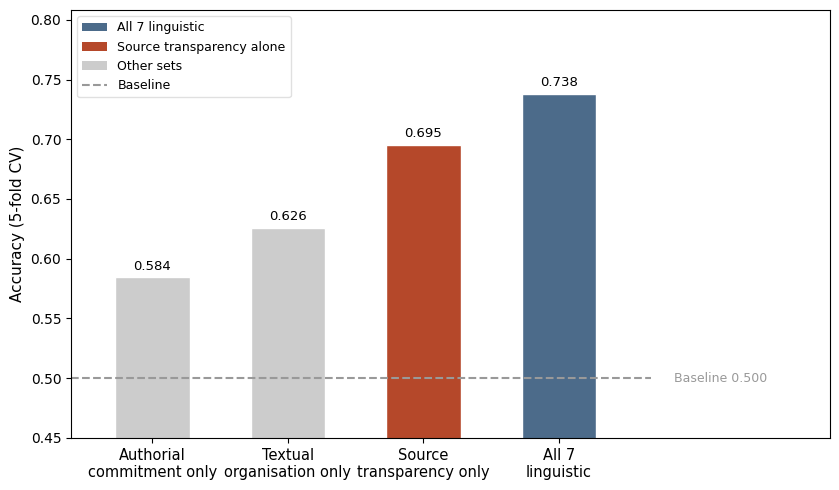

In [20]:
SET_ORDER  = ['Authorial commitment only', 'Textual organisation only',
              'Source transparency only', 'All 7 linguistic']
SET_LABELS = ['Authorial\ncommitment only', 'Textual\norganisation only',
              'Source\ntransparency only', 'All 7\nlinguistic']

valid = [(l, s) for l, s in zip(SET_LABELS, SET_ORDER) if s in results]
plot_labels = [v[0] for v in valid]
acc_vals = [results[v[1]]['acc'] for v in valid]
bar_cols = ['#4C6B8A' if v[1] == 'All 7 linguistic' else
            '#B5482A' if v[1] == 'Source transparency only' else '#CCCCCC' for v in valid]

fig, ax = plt.subplots(figsize=(8.5, 5))
xs, w = np.arange(len(acc_vals)), 0.55
bars = ax.bar(xs, acc_vals, width=w, color=bar_cols, edgecolor='white')
ax.set_xlim(-0.6, len(acc_vals) - 0.5 + 1.5)

ax.axhline(base, color='#999999', linewidth=1.5, linestyle='--',
           xmax=(len(acc_vals) - 0.5 + 0.18 - ax.get_xlim()[0]) / (ax.get_xlim()[1] - ax.get_xlim()[0]))
ax.text(len(acc_vals) - 0.5 + 0.35, base, f'Baseline {base:.3f}',
        color='#999999', fontsize=9, va='center', ha='left')

for rect in bars:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 0.004, f'{h:.3f}',
            ha='center', va='bottom', fontsize=9.5)

ax.set_xticks(xs); ax.set_xticklabels(plot_labels, fontsize=10.5)
ax.set_ylabel('Accuracy (5-fold CV)', fontsize=11)
ax.set_ylim(0.45, max(acc_vals) + 0.07)
# ax.set_title('Classification Accuracy by Feature Set (5-fold CV)', fontsize=13, fontweight='bold', pad=14)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#4C6B8A', label='All 7 linguistic'),
    Patch(facecolor='#B5482A', label='Source transparency alone'),
    Patch(facecolor='#CCCCCC', label='Other sets'),
    plt.Line2D([0],[0], color='#999999', linestyle='--', label='Baseline'),
], fontsize=9, loc='upper left', framealpha=0.9, edgecolor='#DDDDDD')
plt.tight_layout()
plt.savefig('fig3_feature_sets.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

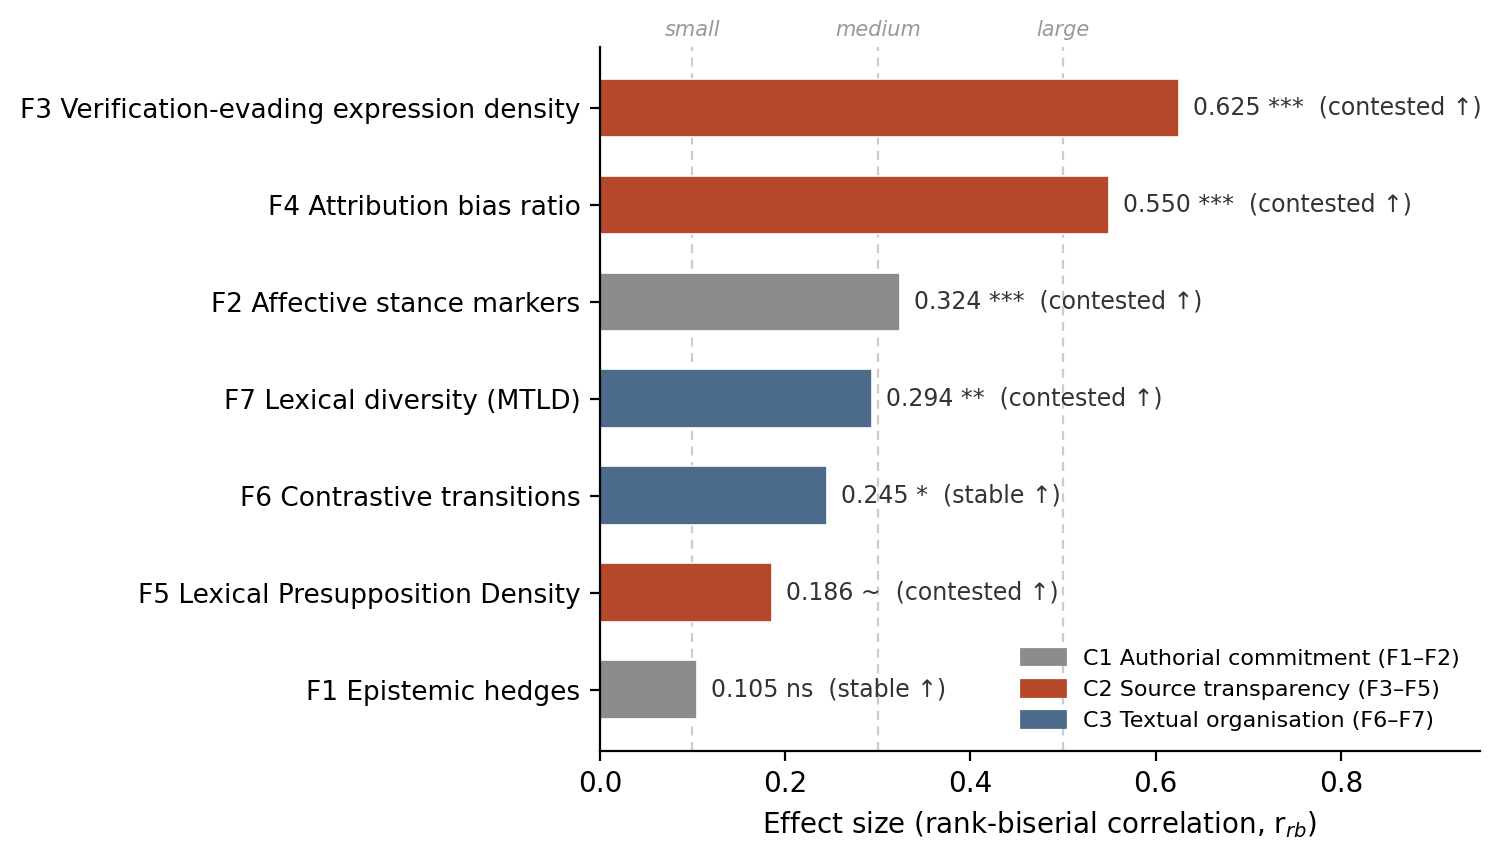

In [21]:
# ── Per-feature effect size ranking, with direction ────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CAT_COLOR = {"C1": "#8C8C8C", "C2": "#B5482A", "C3": "#4C6B8A"}
CAT_LABEL = {
    "C1": "C1 Authorial commitment (F1\u2013F2)",
    "C2": "C2 Source transparency (F3\u2013F5)",
    "C3": "C3 Textual organisation (F6\u2013F7)",
}

# direction_higher: 'C' = contested组更高, 'S' = stable组更高（来自cell 22的Diff%符号）
DIRECTION = {
    'f1_hedge': 'S', 'f2_affective': 'C', 'f3_verification_evading': 'C',
    'f4_attrib_bias': 'C', 'f5_presupposition': 'C', 'f6_contrastive': 'S', 'f7_mtld': 'C',
}

data_sorted = sorted(raw_results, key=lambda r: r['r_rb'], reverse=True)
labels = [LABELS[r['feature']] for r in data_sorted]
values = [r['r_rb'] for r in data_sorted]
sigs   = [r['sig'] for r in data_sorted]
colors = [CAT_COLOR[CATEGORY_MAP[r['feature']]] for r in data_sorted]
dirs   = [DIRECTION[r['feature']] for r in data_sorted]

fig, ax = plt.subplots(figsize=(7.6, 4.4), dpi=200)
y_pos = np.arange(len(labels))[::-1]
bars = ax.barh(y_pos, values, color=colors, height=0.6, edgecolor='white', linewidth=0.6)

for thresh in [0.1, 0.3, 0.5]:
    ax.axvline(thresh, color='#CCCCCC', linewidth=0.8, linestyle=(0, (4, 3)), zorder=0)

for y, v, s, d in zip(y_pos, values, sigs, dirs):
    dir_text = "contested \u2191" if d == 'C' else "stable \u2191"
    ax.text(v + 0.015, y, f"{v:.3f} {s}  ({dir_text})", va='center', ha='left', fontsize=8.5, color='#333333')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9.5)
ax.set_xlabel("Effect size (rank-biserial correlation, r$_{rb}$)", fontsize=10)
ax.set_xlim(0, 0.95)
for thresh, name in [(0.1, "small"), (0.3, "medium"), (0.5, "large")]:
    ax.text(thresh, len(labels)-0.3, name, fontsize=7.5, color='#999999', ha='center', va='bottom', style='italic')

legend_patches = [mpatches.Patch(color=CAT_COLOR[c], label=CAT_LABEL[c]) for c in ["C1","C2","C3"]]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig('fig1_per_feature_with_direction.png', dpi=200, bbox_inches='tight')
plt.show()

In [22]:
# ── Diagnostic 1: pairwise/combined fits across ALL 7 features ──
# Tests whether any pair of features competes for the same direction of effect when fit together, across the full feature set.
import itertools

all_feats = LING_FEATURES  # all 7 features
d_all = df[all_feats + ['label']].dropna()
y_all = d_all['label'].values

print('Pairwise fits (every 2-feature combination among all 7 features):')
for combo in itertools.combinations(all_feats, 2):
    X = StandardScaler().fit_transform(d_all[list(combo)].values)
    lr_c = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    lr_c.fit(X, y_all)
    coefs = dict(zip(combo, lr_c.coef_[0]))
    coef_str = ', '.join(f'{LABELS[k]}={v:+.3f}' for k, v in coefs.items())
    print(f'  {coef_str}')

print('\nSolo fits, for comparison (each feature alone):')
for f in all_feats:
    X = StandardScaler().fit_transform(d_all[[f]].values)
    lr_s = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    lr_s.fit(X, y_all)
    print(f'  {LABELS[f]}={lr_s.coef_[0][0]:+.3f}')

Pairwise fits (every 2-feature combination among all 7 features):
  F1 Epistemic hedges=+0.308, F2 Affective stance markers=-0.800
  F1 Epistemic hedges=+0.233, F3 Verification-evading expression density=-0.702
  F1 Epistemic hedges=+0.199, F4 Attribution bias ratio=-0.908
  F1 Epistemic hedges=+0.108, F5 Lexical Presupposition Density=-0.196
  F1 Epistemic hedges=+0.003, F6 Contrastive transitions=+0.474
  F1 Epistemic hedges=+0.309, F7 Lexical diversity (MTLD)=-0.583
  F2 Affective stance markers=-0.672, F3 Verification-evading expression density=-0.571
  F2 Affective stance markers=-0.591, F4 Attribution bias ratio=-0.837
  F2 Affective stance markers=-0.907, F5 Lexical Presupposition Density=-0.428
  F2 Affective stance markers=-0.829, F6 Contrastive transitions=+0.572
  F2 Affective stance markers=-0.579, F7 Lexical diversity (MTLD)=-0.306
  F3 Verification-evading expression density=-0.532, F4 Attribution bias ratio=-0.829
  F3 Verification-evading expression density=-0.695, F5 L

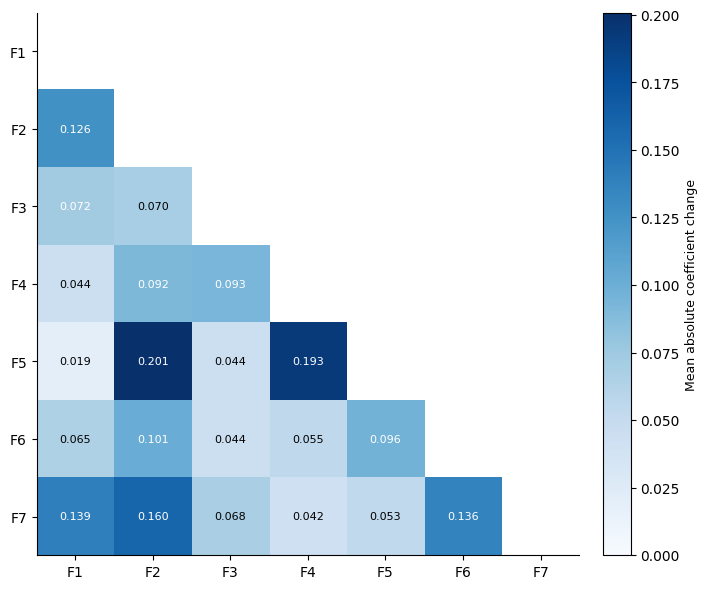

Saved: fig_pairwise_heatmap.png


In [23]:
# ── Figure: Pairwise feature interaction heatmap ─────────────────────────────
# Visualizes how much each feature's coefficient changes when paired with
# every other feature, relative to its solo-fit coefficient.
# Requires: LING_FEATURES, LABELS, df, label column already in session.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from itertools import combinations

d = df[LING_FEATURES + ['label']].dropna()
y = d['label'].values

# Solo-fit coefficients (each feature alone)
solo_coef = {}
for f in LING_FEATURES:
    X_solo = StandardScaler().fit_transform(d[[f]].values)
    lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    lr.fit(X_solo, y)
    solo_coef[f] = lr.coef_[0][0]

# Pairwise-fit coefficients (all 21 combinations)
change_matrix = pd.DataFrame(np.nan, index=LING_FEATURES, columns=LING_FEATURES)

for f1, f2 in combinations(LING_FEATURES, 2):
    X_pair = StandardScaler().fit_transform(d[[f1, f2]].values)
    lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    lr.fit(X_pair, y)
    c1, c2 = lr.coef_[0]
    delta1 = abs(abs(c1) - abs(solo_coef[f1]))
    delta2 = abs(abs(c2) - abs(solo_coef[f2]))
    change_matrix.loc[f1, f2] = delta1
    change_matrix.loc[f2, f1] = delta2

sym_matrix = (change_matrix + change_matrix.T) / 2

short_labels = [LABELS[f].split()[0] for f in LING_FEATURES]

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(sym_matrix, dtype=bool))
data_masked = np.ma.masked_where(mask, sym_matrix.values)

im = ax.imshow(data_masked, cmap='Blues', vmin=0)
ax.set_xticks(range(len(LING_FEATURES)))
ax.set_yticks(range(len(LING_FEATURES)))
ax.set_xticklabels(short_labels, fontsize=10)
ax.set_yticklabels(short_labels, fontsize=10)

vmax = sym_matrix.values[~np.isnan(sym_matrix.values)].max()
threshold = vmax * 0.35  # lower threshold so more dark cells get white text

for i in range(len(LING_FEATURES)):
    for j in range(len(LING_FEATURES)):
        if i > j:
            val = sym_matrix.values[i, j]
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                     fontsize=8, color='white' if val > threshold else 'black')

# ax.set_title('Coefficient change when paired with another feature\n(absolute change vs. solo-fit coefficient)',
#               fontsize=11, fontweight='bold', pad=12)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Mean absolute coefficient change', fontsize=9)
plt.tight_layout()
plt.savefig('fig_pairwise_heatmap.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig_pairwise_heatmap.png')

In [24]:
# ── Diagnostic 2: is F4's missingness pattern related to label? ──
# F4 is the only one of the 7 features with missing values, so this check remains specific to F4.
import scipy.stats as stats

f4_missing = df['f4_attrib_bias'].isna()
contingency = pd.crosstab(df['label'], f4_missing)
print('F4 missingness x label contingency table:')
print(contingency)
print('\n(rows: 0 = contested, 1 = stable; columns: False = has value, True = missing)')

chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f'\nChi-square test: chi2={chi2:.3f}, p={p:.4f}')
print('If p < 0.05, missingness is significantly associated with label, meaning the')
print('233 complete cases after dropna() are not a random subset. This should be')
print('reported in the Validation section.')

F4 missingness x label contingency table:
f4_attrib_bias  False  True 
label                       
0                 122     21
1                 111     32

(rows: 0 = contested, 1 = stable; columns: False = has value, True = missing)

Chi-square test: chi2=2.316, p=0.1281
If p < 0.05, missingness is significantly associated with label, meaning the
233 complete cases after dropna() are not a random subset. This should be
reported in the Validation section.


In [25]:
# ── Diagnostic 3: refit after trimming extreme outliers (IQR-based), all 7 features ──
# Tests whether each feature's discriminative direction is driven by a small
# number of extreme samples, using two trimming thresholds (k=3.0 lenient, k=1.5 strict).

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

def remove_outliers_iqr(data, col, k):
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return data[(data[col] >= lo) & (data[col] <= hi)]

# Original (no trimming) coefficients, refit here for a clean baseline
d_full = df[LING_FEATURES + ['label']].dropna()
X_full = StandardScaler().fit_transform(d_full[LING_FEATURES].values)
y_full = d_full['label'].values
lr_orig = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_orig.fit(X_full, y_full)

# ── k = 3.0 (lenient trimming) ──────────────────────────────────────────────
d_trimmed_30 = df[LING_FEATURES + ['label']].dropna()
for f in LING_FEATURES:
    d_trimmed_30 = remove_outliers_iqr(d_trimmed_30, f, k=3.0)

X_trim30 = StandardScaler().fit_transform(d_trimmed_30[LING_FEATURES].values)
y_trim30 = d_trimmed_30['label'].values
lr_trim30 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_trim30.fit(X_trim30, y_trim30)

print(f'Sample size after removing outliers (k=3.0): {len(d_trimmed_30)} / {len(d_full)}')

# ── k = 1.5 (strict trimming) ───────────────────────────────────────────────
d_trimmed_15 = df[LING_FEATURES + ['label']].dropna()
for f in LING_FEATURES:
    d_trimmed_15 = remove_outliers_iqr(d_trimmed_15, f, k=1.5)

X_trim15 = StandardScaler().fit_transform(d_trimmed_15[LING_FEATURES].values)
y_trim15 = d_trimmed_15['label'].values
lr_trim15 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_trim15.fit(X_trim15, y_trim15)

print(f'Sample size after removing outliers (k=1.5): {len(d_trimmed_15)} / {len(d_full)}')

# ── Compare all three: original, k=3.0, k=1.5 ───────────────────────────────
print(f'\n{"Feature":<30} {"Original coef":>14} {"k=3.0 coef":>12} {"k=1.5 coef":>12} {"Direction changed?":>20}')
print('-' * 92)
for i, f in enumerate(LING_FEATURES):
    orig   = lr_orig.coef_[0][i]
    trim30 = lr_trim30.coef_[0][i]
    trim15 = lr_trim15.coef_[0][i]
    changed = 'Yes' if (orig > 0) != (trim15 > 0) else 'No'
    print(f'{LABELS[f]:<30} {orig:>+14.3f} {trim30:>+12.3f} {trim15:>+12.3f} {changed:>20}')

Sample size after removing outliers (k=3.0): 225 / 233
Sample size after removing outliers (k=1.5): 194 / 233

Feature                         Original coef   k=3.0 coef   k=1.5 coef   Direction changed?
--------------------------------------------------------------------------------------------
F1 Epistemic hedges                    +0.444       +0.275       +0.266                   No
F2 Affective stance markers            -0.726       -0.621       -0.422                   No
F3 Verification-evading expression density         -0.541       -0.869       -0.661                   No
F4 Attribution bias ratio              -0.972       -0.914       -0.822                   No
F5 Lexical Presupposition Density         -0.428       -0.473       -0.509                   No
F6 Contrastive transitions             +0.499       +0.492       +0.436                   No
F7 Lexical diversity (MTLD)            -0.451       -0.345       -0.309                   No


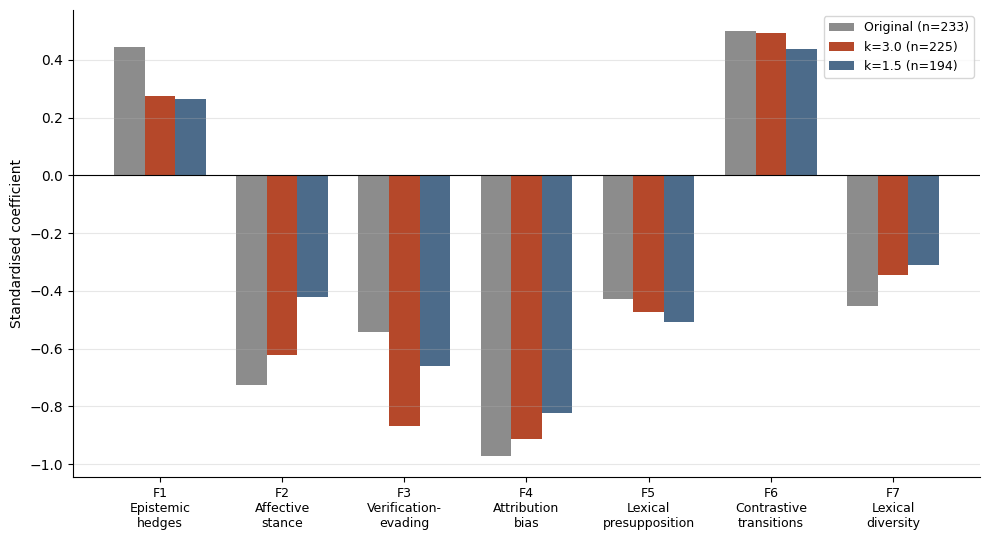

Saved: fig_outlier_robustness.png


In [30]:
features = ['F1\nEpistemic\nhedges', 'F2\nAffective\nstance', 'F3\nVerification-\nevading',
            'F4\nAttribution\nbias', 'F5\nLexical\npresupposition', 'F6\nContrastive\ntransitions',
            'F7\nLexical\ndiversity']
original = [0.444, -0.726, -0.541, -0.972, -0.428, 0.499, -0.451]
k30       = [0.275, -0.621, -0.869, -0.914, -0.473, 0.492, -0.345]
k15       = [0.266, -0.422, -0.661, -0.822, -0.509, 0.436, -0.309]

CAT_COLOR = {"C1": "#8C8C8C", "C2": "#B5482A", "C3": "#4C6B8A"}

x = np.arange(len(features))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - width, original, width, label='Original (n=233)', color=CAT_COLOR['C1'])
ax.bar(x,         k30,      width, label='k=3.0 (n=225)',     color=CAT_COLOR['C2'])
ax.bar(x + width, k15,      width, label='k=1.5 (n=194)',     color=CAT_COLOR['C3'])

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(features, fontsize=9)
ax.set_ylabel('Standardised coefficient')
#ax.set_title('Coefficient stability under outlier trimming')
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_outlier_robustness.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig_outlier_robustness.png')

## 12. Permutation Test

In [26]:
n_permutations = 1000
perm_sig_counts = []
rng = np.random.default_rng(seed=42)  # fixed seed for reproducibility

for _ in range(n_permutations):
    perm_diffs = diff_df[LING_FEATURES].copy()
    # Randomly flip signs row-wise (each pair independently)
    signs = rng.choice([-1, 1], size=len(perm_diffs))
    perm_diffs = perm_diffs.multiply(signs, axis=0)

    p_vals_perm = []
    for f in LING_FEATURES:
        vals = perm_diffs[f].dropna()
        if len(vals) < 5: continue
        _, p = wilcoxon(vals)
        p_vals_perm.append(p)
    if not p_vals_perm: continue
    _, p_holm_perm, _, _ = multipletests(p_vals_perm, method='holm')
    perm_sig_counts.append(sum(p < 0.05 for p in p_holm_perm))

real_sig = n_sig
p_perm   = np.mean(np.array(perm_sig_counts) >= real_sig)
print(f'Observed significant features : {real_sig}/{len(LING_FEATURES)}')
print(f'Permutation mean under null   : {np.mean(perm_sig_counts):.2f}')
print(f'Permutation p-value           : {p_perm:.4f}')

Observed significant features : 5/7
Permutation mean under null   : 0.05
Permutation p-value           : 0.0000


## 13. AUC (ROC)

In [27]:
from sklearn.metrics import roc_auc_score

d   = df[LING_FEATURES + ['label']].dropna()
X   = StandardScaler().fit_transform(d[LING_FEATURES].values)
y   = d['label'].values

cv_auc  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_auc  = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
aucs    = cross_val_score(lr_auc, X, y, cv=cv_auc, scoring='roc_auc')
accs    = cross_val_score(lr_auc, X, y, cv=cv_auc, scoring='accuracy')

print(f'AUC (5-fold CV)  : {aucs.mean():.3f} +/- {aucs.std():.3f}')
print(f'Accuracy (5-fold): {accs.mean():.3f} +/- {accs.std():.3f}')
print(f'Baseline (random): 0.500')

AUC (5-fold CV)  : 0.823 +/- 0.060
Accuracy (5-fold): 0.738 +/- 0.059
Baseline (random): 0.500
